# Batch Normalization

## Importing Necessary Libraries

In [9]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

## Loading the Dataset

In [10]:
X, y = make_moons(10000, noise=0.8, random_state=42)

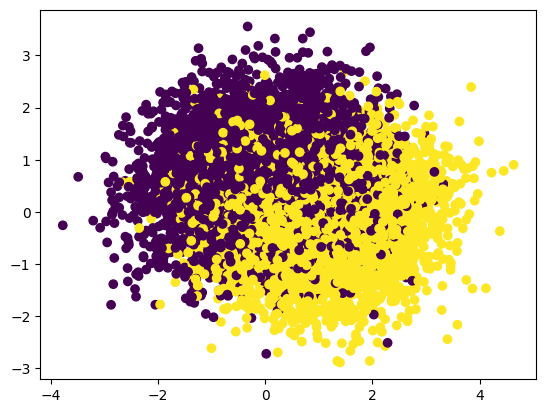

In [11]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

## Model Building without Batch Normalization

In [12]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(30, activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571 (2.23 KB)

 Trainable params: 571 (2.23 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [15]:
history = model.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6447 - loss: 0.6211 - val_accuracy: 0.7325 - val_loss: 0.5368
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7576 - loss: 0.5054 - val_accuracy: 0.7325 - val_loss: 0.5334
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7407 - loss: 0.5151 - val_accuracy: 0.7350 - val_loss: 0.5332
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7383 - loss: 0.5173 - val_accuracy: 0.7360 - val_loss: 0.5344
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7406 - loss: 0.5113 - val_accuracy: 0.7355 - val_loss: 0.5333
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7442 - loss: 0.5133 - val_accuracy: 0.7325 - val_loss: 0.5336
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7449 - loss: 0.5082 - val_accuracy: 0.7340 - val_loss: 0.5316
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7549 - loss: 0.5049 - val_accuracy: 0.7355

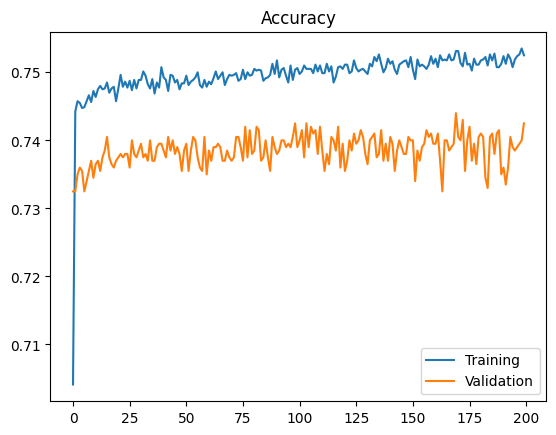

In [16]:
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

## Model Building with Batch Normalization

In [17]:
model_2 = keras.Sequential(
    [
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(30, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1, activation='sigmoid')
    ]
)


In [18]:
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 30)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15)             │            60 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751 (2.93 KB)

 Trainable params: 661 (2.58 KB)

 Non-trainable params: 90 (360.00 B)

In [19]:
model_2.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [20]:
history_2 = model_2.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6421 - loss: 0.6447 - val_accuracy: 0.7305 - val_loss: 0.5596
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7391 - loss: 0.5196 - val_accuracy: 0.7400 - val_loss: 0.5307
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7464 - loss: 0.5178 - val_accuracy: 0.7435 - val_loss: 0.5309
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7349 - loss: 0.5345 - val_accuracy: 0.7400 - val_loss: 0.5316
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7406 - loss: 0.5206 - val_accuracy: 0.7430 - val_loss: 0.5300
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7389 - loss: 0.5252 - val_accuracy: 0.7370 - val_loss: 0.5297
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7446 - loss: 0.5162 - val_accuracy: 0.7440 - val_loss: 0.5292
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7358 - loss: 0.5270 - val_accu

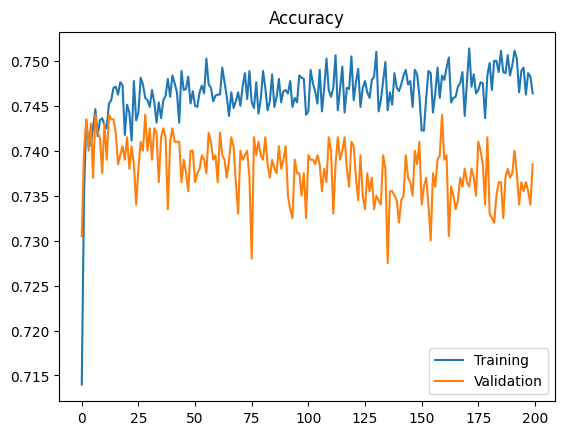

In [21]:
plt.plot(history_2.history['accuracy'], label='Training')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

## Batch Normalization vs No Batch Normalization

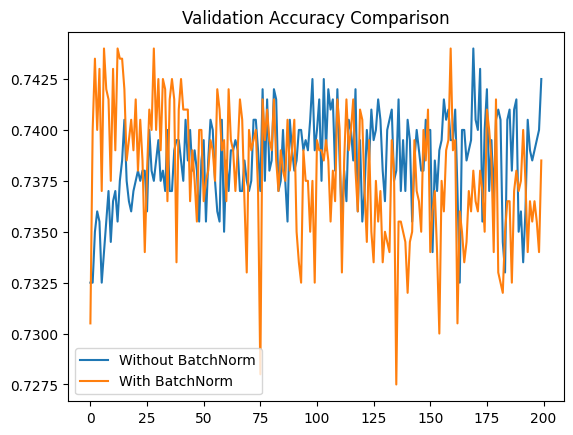

In [22]:
plt.plot(history.history['val_accuracy'], label='Without BatchNorm')
plt.plot(history_2.history['val_accuracy'], label='With BatchNorm')
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()